# 2. Deeper Exploratory Data Analysis and Data Preparation

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2.1 Load the Cleaned Labeled Dataset

In [2]:
# Resolve the project root so the notebook works across different systems
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

processed_path = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "elliptic_labeled_transactions.csv"
)

filtered_df = pd.read_csv(processed_path)

print("Processed dataset loaded successfully.")
print("Shape:", filtered_df.shape)
print(f"Total columns: {filtered_df.shape[1]}")
display(filtered_df.iloc[:5, :12])

Processed dataset loaded successfully.
Shape: (46564, 169)
Total columns: 169


,txId,time_step,2,3,4,5,6,7,8,9,10,11
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,0.043598
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,-0.144554,0.020069
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,-0.169115,-0.047227


## 2.2 Confirm Data Types and Basic Structure

In [3]:
print(filtered_df.info())

print("\nColumns:")
print(filtered_df.columns.tolist()[:20], "...")

<class 'pandas.DataFrame'>
RangeIndex: 46564 entries, 0 to 46563
Columns: 169 entries, txId to label
dtypes: float64(165), int64(4)
memory usage: 60.0 MB
None

Columns:
['txId', 'time_step', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19'] ...


## 2.3 Class Balance Summary

In [4]:
label_counts = filtered_df["label"].value_counts().sort_index()
label_percentages = filtered_df["label"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(label_counts)

print("\nClass percentages:")
print(f"Licit (0): {label_percentages[0]:.2f}%")
print(f"Illicit (1): {label_percentages[1]:.2f}%")

Class counts:
label
0    42019
1     4545
Name: count, dtype: int64

Class percentages:
Licit (0): 90.24%
Illicit (1): 9.76%


The labeled subset is strongly imbalanced, with licit transactions forming the clear majority. This is consistent with real-world fraud detection settings, where illicit activity is relatively rare. Therefore, later model evaluation should focus on precision, recall, F1-score, and PR-AUC rather than relying on accuracy alone.

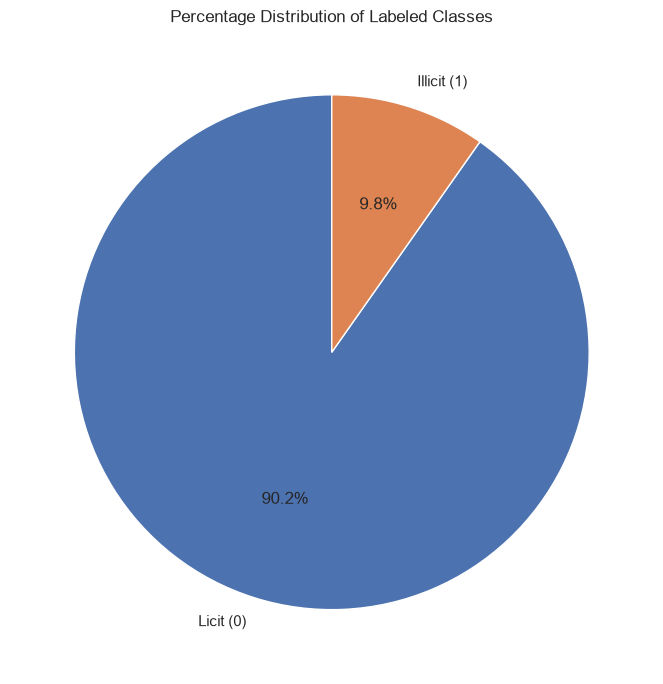

In [5]:
plt.figure(figsize=(7, 7))
plt.pie(
    label_counts.values,
    labels=["Licit (0)", "Illicit (1)"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of Labeled Classes")
plt.tight_layout()
plt.show()

## 2.4 Feature Group Definition

In [6]:
non_feature_cols = ["txId", "time_step", "class", "label"]
feature_cols = [col for col in filtered_df.columns if col not in non_feature_cols]

print("Number of feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

Number of feature columns: 165
First 10 feature columns: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11']


In [7]:
selected_features = feature_cols[:10]

feature_summary = filtered_df[selected_features].describe().T
display(feature_summary)

,count,mean,std,min,25%,50%,75%,max
2,46564.0,-0.052645,0.702554,-0.172982,-0.172683,-0.170652,-0.141446,39.786756
3,46564.0,0.159103,1.544040,-0.210553,-0.162140,-0.113851,0.016948,73.595052
4,46564.0,0.148974,1.063158,-1.756361,-1.201369,0.463609,1.018602,2.683580
5,46564.0,0.172216,1.600931,-0.121970,-0.121970,-0.121970,0.028105,49.027598
6,46564.0,0.028651,1.729706,-0.063725,-0.043875,-0.043875,-0.043875,260.090707
7,46564.0,0.184429,1.589399,-0.113002,-0.113002,-0.113002,-0.029140,54.565178
8,46564.0,-0.015381,0.577378,-0.061584,-0.061584,-0.061584,-0.061584,44.365651
9,46564.0,-0.077488,0.588778,-0.163646,-0.163614,-0.163383,-0.158465,40.721063
10,46564.0,-0.059497,0.667889,-0.169460,-0.169230,-0.167581,-0.145476,40.142250
11,46564.0,0.099852,1.864245,-0.049707,-0.049707,-0.049707,-0.043681,189.186944


Although the Elliptic feature columns are anonymized, their descriptive statistics still provide useful information about variation, scale, and potential preprocessing needs. Since the numerical ranges differ across features, feature scaling may be worth considering for some baseline models such as Logistic Regression.

## 2.5 Temporal Analysis

In [8]:
time_step_summary = (
    filtered_df.groupby("time_step")
    .agg(
        total_transactions=("label", "count"),
        illicit_transactions=("label", "sum")
    )
    .reset_index()
)

time_step_summary["licit_transactions"] = (
    time_step_summary["total_transactions"] - time_step_summary["illicit_transactions"]
)

time_step_summary["illicit_ratio"] = (
    time_step_summary["illicit_transactions"] / time_step_summary["total_transactions"]
)

display(time_step_summary.head(10))

,time_step,total_transactions,illicit_transactions,licit_transactions,illicit_ratio
0,1,2147,17,2130,0.007918
1,2,1117,18,1099,0.016115
2,3,1279,11,1268,0.008600
3,4,1440,30,1410,0.020833
4,5,1882,8,1874,0.004251
5,6,485,5,480,0.010309
6,7,1203,102,1101,0.084788
7,8,1165,67,1098,0.057511
8,9,778,248,530,0.318766
9,10,972,18,954,0.018519


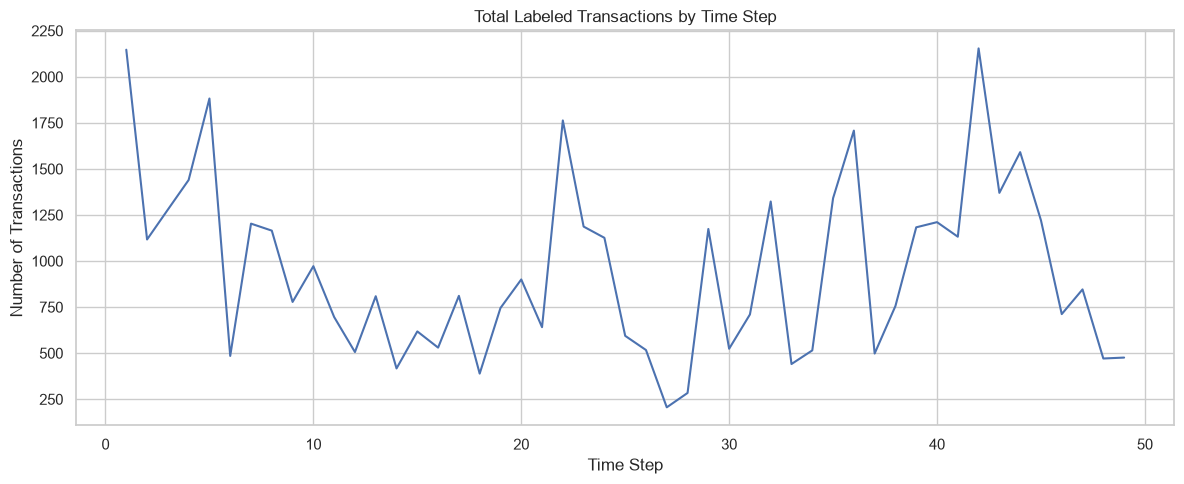

In [9]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=time_step_summary, x="time_step", y="total_transactions")
plt.title("Total Labeled Transactions by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

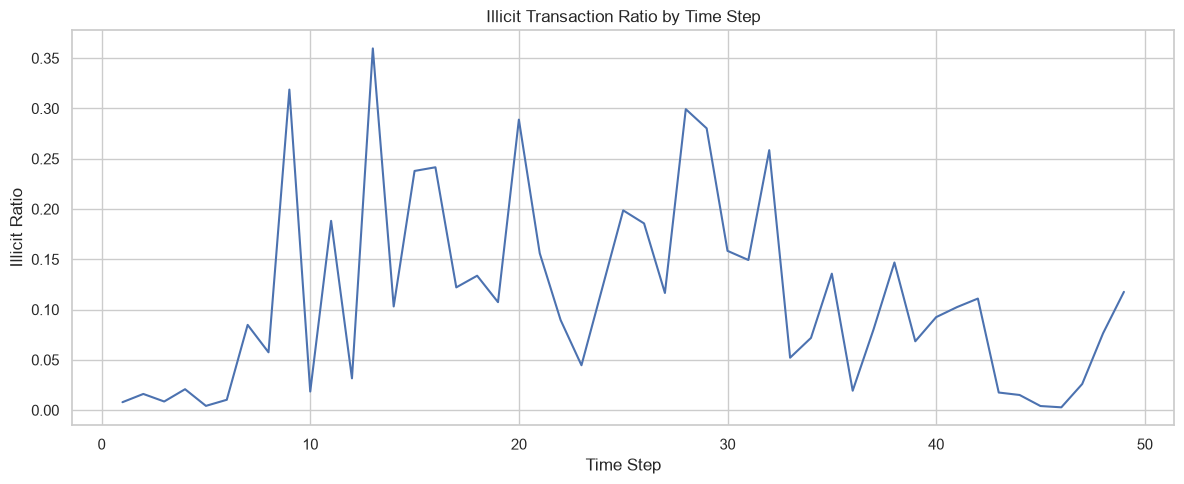

In [10]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=time_step_summary, x="time_step", y="illicit_ratio")
plt.title("Illicit Transaction Ratio by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Illicit Ratio")
plt.tight_layout()
plt.show()

The time-step analysis shows not only how labeled activity changes over time, but also whether the proportion of illicit transactions remains stable or fluctuates. This is useful because temporal instability may affect how well a model generalizes from one portion of the dataset to another.

## 2.6 Correlation Analysis on a Selected Feature Subset

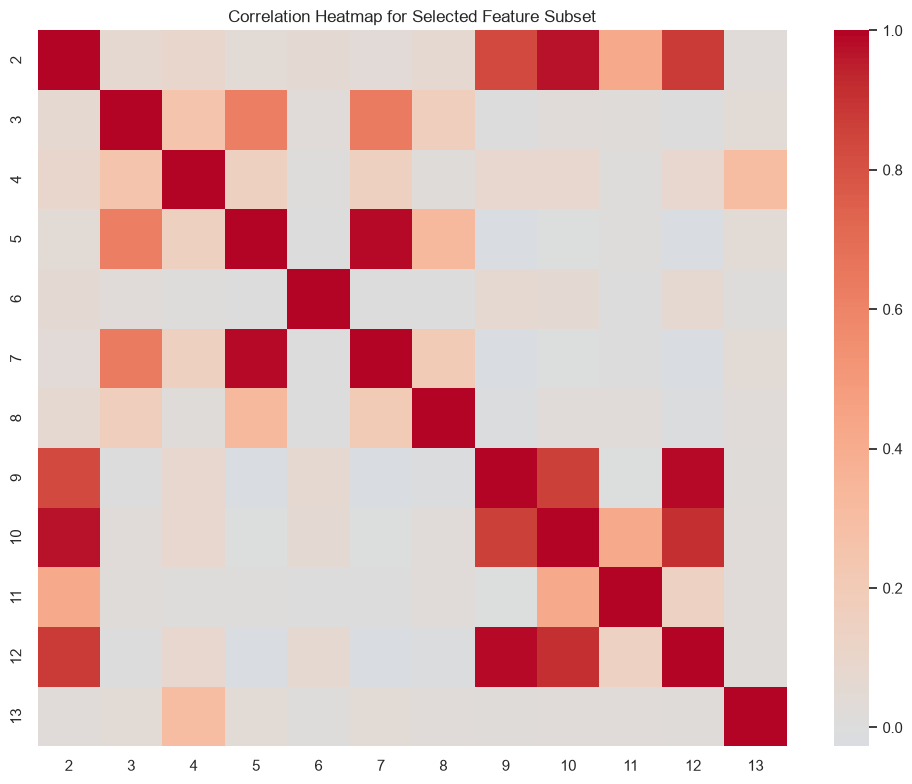

In [11]:
corr_features = feature_cols[:12]
corr_matrix = filtered_df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for Selected Feature Subset")
plt.tight_layout()
plt.show()

In [12]:
feature_variances = filtered_df[feature_cols].var().sort_values(ascending=False)
top_variance_features = feature_variances.head(10)

print("Top 10 highest-variance features:")
display(top_variance_features)

Top 10 highest-variance features:


35    4.350456
43    4.281634
31    4.276655
25    4.276653
49    4.210252
38    4.154775
36    4.111289
39    4.081967
40    4.080952
30    4.013693
dtype: float64

The highest-variance features may capture stronger differentiation among transactions, although high variance alone does not imply predictive importance. Still, this provides a useful initial view of which variables appear most dynamic within the labeled subset.

## 2.7 Distribution of Selected Features by Class

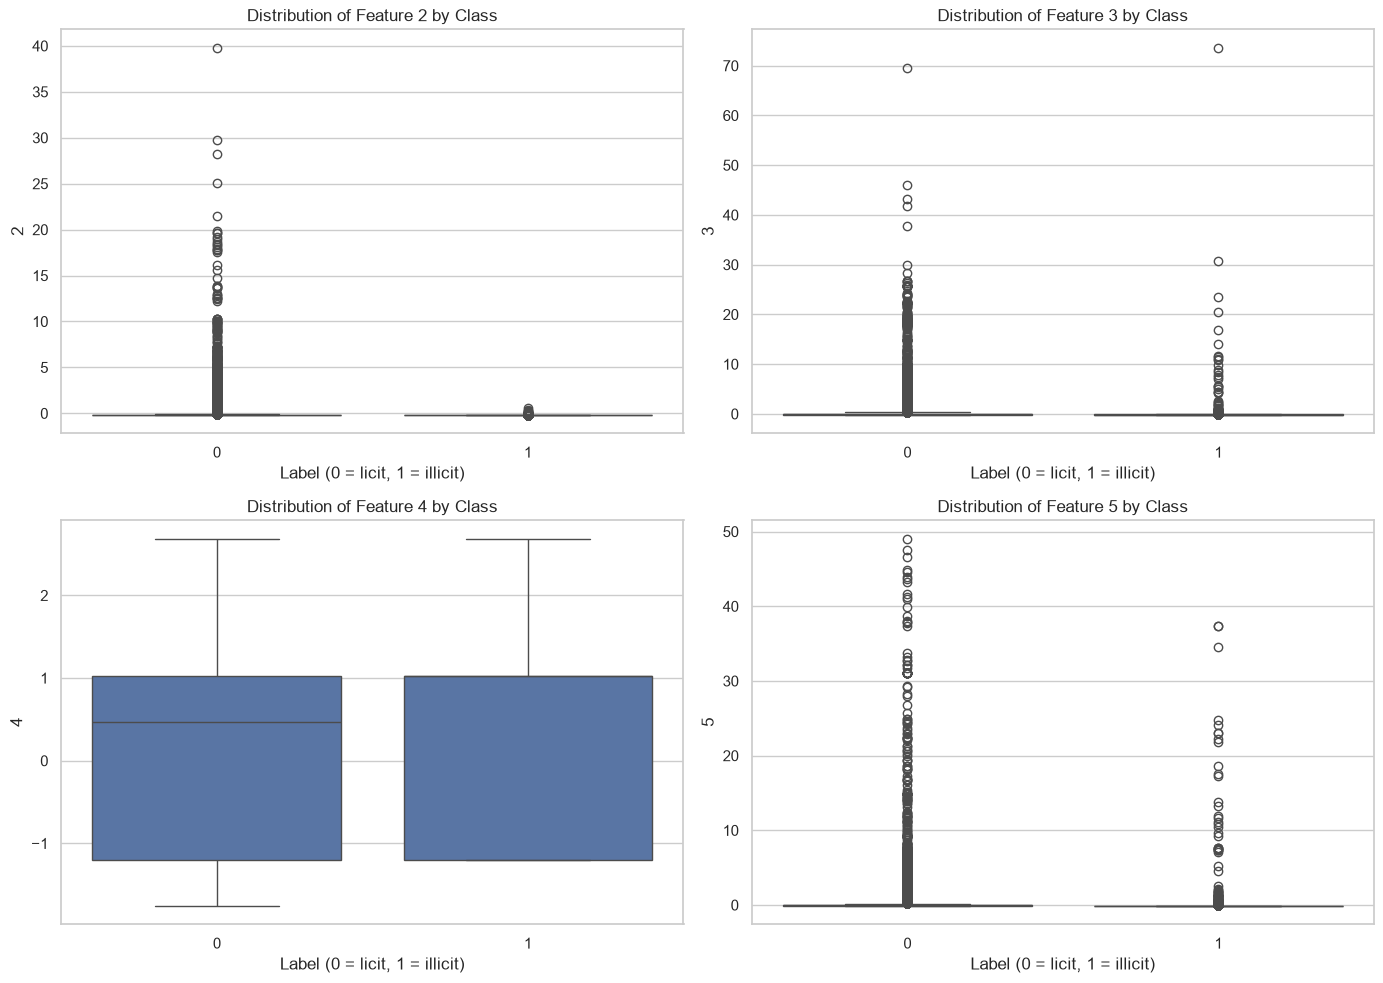

In [13]:
plot_features = feature_cols[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    sns.boxplot(data=filtered_df, x="label", y=feature, ax=ax)
    ax.set_title(f"Distribution of Feature {feature} by Class")
    ax.set_xlabel("Label (0 = licit, 1 = illicit)")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 2.8 Prepare Feature Matrix and Target Variable

In [14]:
X = filtered_df[feature_cols].copy()
y = filtered_df["label"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (46564, 165)
Target shape: (46564,)


## 2.9 Train, Validation, and Test Split

In [15]:
# First split: train+val and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size = 0.25,   # 0.25 of 0.80 = 0.20
    stratify = y_train_val,
    random_state = 42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (27938, 165) (27938,)
Validation shape: (9313, 165) (9313,)
Test shape: (9313, 165) (9313,)


In [16]:
def summarize_split(name, y_values):
    counts = y_values.value_counts().sort_index()
    percentages = y_values.value_counts(normalize=True).sort_index() * 100

    print(f"{name} split:")
    print("Counts:")
    print(counts)
    print("Percentages:")
    print(percentages.round(2))
    print("-" * 40)

summarize_split("Train", y_train)
summarize_split("Validation", y_val)
summarize_split("Test", y_test)

Train split:
Counts:
label
0    25211
1     2727
Name: count, dtype: int64
Percentages:
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------
Validation split:
Counts:
label
0    8404
1     909
Name: count, dtype: int64
Percentages:
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------
Test split:
Counts:
label
0    8404
1     909
Name: count, dtype: int64
Percentages:
label
0    90.24
1     9.76
Name: proportion, dtype: float64
----------------------------------------


The stratified split preserves the class imbalance pattern across train, validation, and test sets. This is important because it ensures that later model comparisons are made under realistic class distributions rather than artificially balanced partitions.

## 2.10 Save Prepared Tabular Datasets

In [17]:
split_dir = PROJECT_DIR / "data" / "processed" / "tabular_splits"
split_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(split_dir / "X_train.csv", index=False)
X_val.to_csv(split_dir / "X_val.csv", index=False)
X_test.to_csv(split_dir / "X_test.csv", index=False)

y_train.to_csv(split_dir / "y_train.csv", index=False)
y_val.to_csv(split_dir / "y_val.csv", index=False)
y_test.to_csv(split_dir / "y_test.csv", index=False)

print("Saved train/validation/test splits to:")
print(split_dir.relative_to(PROJECT_DIR))

Saved train/validation/test splits to:
data\processed\tabular_splits


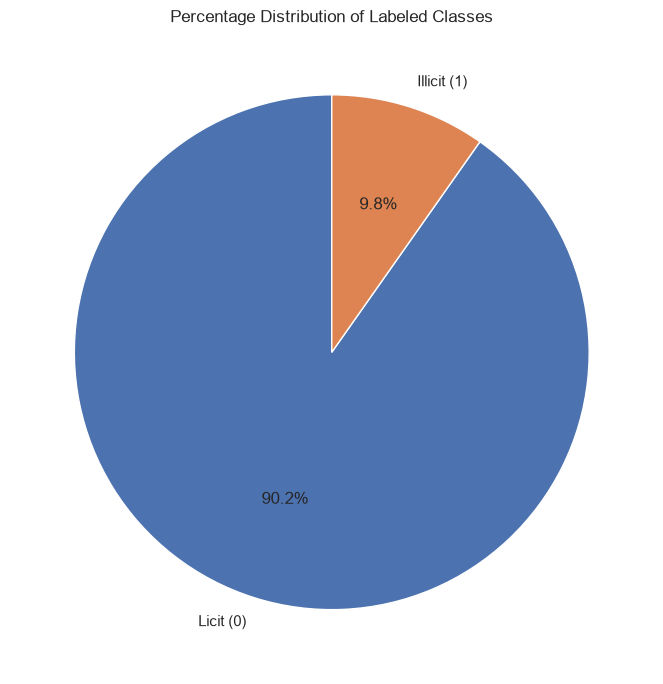

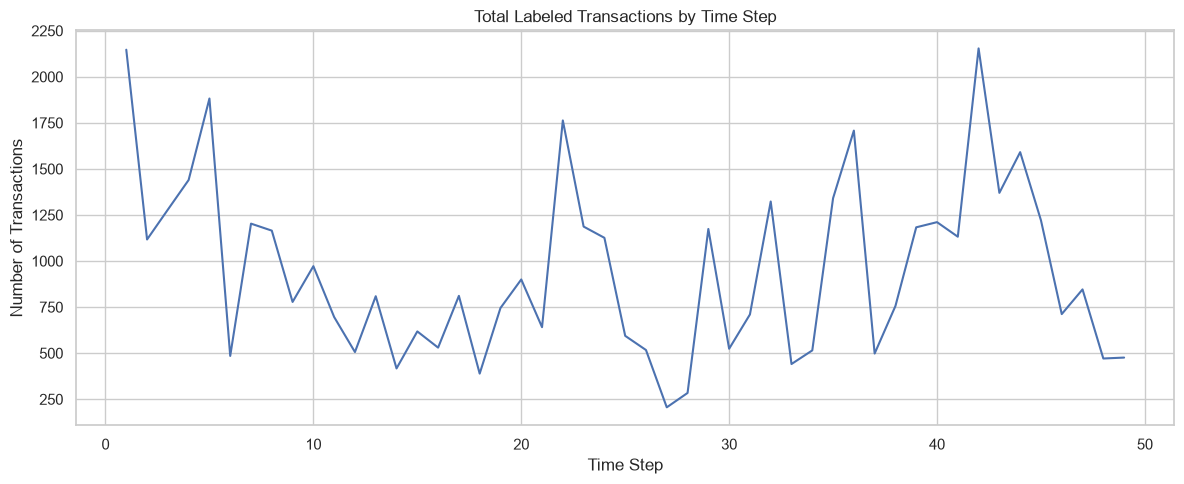

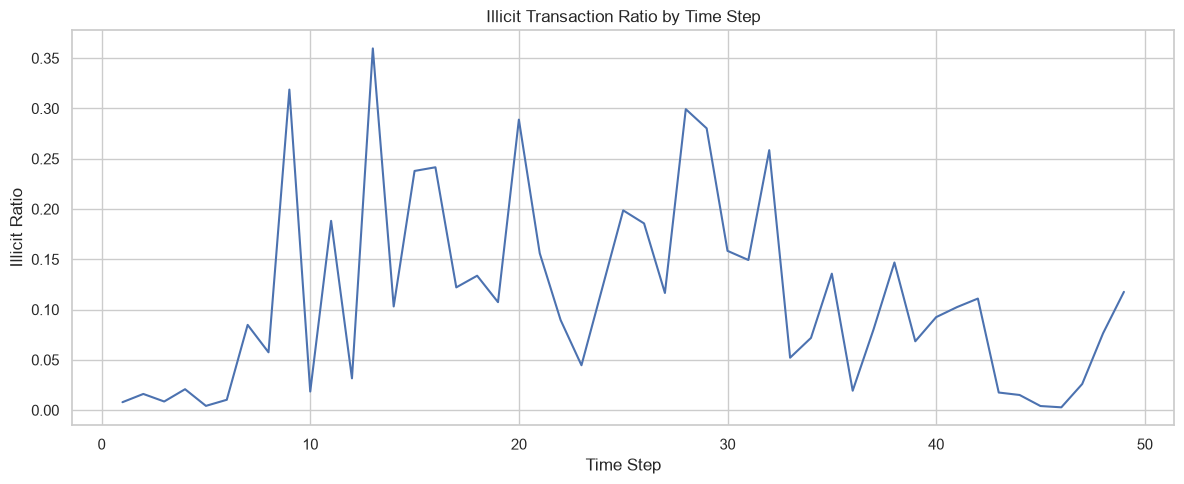

Additional figures saved to: figures


In [18]:
figures_dir = PROJECT_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    label_counts.values,
    labels=["Licit (0)", "Illicit (1)"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of Labeled Classes")
plt.tight_layout()
plt.savefig(figures_dir / "class_percentage_pie.png", dpi=300)
plt.show()

# Total transactions by time step
plt.figure(figsize=(12, 5))
sns.lineplot(data=time_step_summary, x="time_step", y="total_transactions")
plt.title("Total Labeled Transactions by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(figures_dir / "total_transactions_by_time_step.png", dpi=300)
plt.show()

# Illicit ratio by time step
plt.figure(figsize=(12, 5))
sns.lineplot(data=time_step_summary, x="time_step", y="illicit_ratio")
plt.title("Illicit Transaction Ratio by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Illicit Ratio")
plt.tight_layout()
plt.savefig(figures_dir / "illicit_ratio_by_time_step.png", dpi=300)
plt.show()

print("Additional figures saved to:", figures_dir.relative_to(PROJECT_DIR))